
# Лабораторная работа №3. Фильтрация шумов на изображении. 

## Цель работы 
изучение и экспериментальное исследование методов фильтрации аддитивных и импульсных шумов на изображениях при помощи линейного и медианного фильтров.

## Выполнил:
Богачев Матвей 6511 



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from scipy.signal import convolve2d
from scipy.ndimage import median_filter

# Аддитивный белый шум

In [12]:
def generate_chessboard(size=128, squares=8):
    """
    Генерация шахматного поля
    
    Parameters:
    size - размер изображения в пикселях
    squares - количество клеток по одной стороне
    """
    square_size = size // squares
    chessboard = np.zeros((size, size), dtype=np.uint8)
    
    for i in range(squares):
        for j in range(squares):
            if (i + j) % 2 == 0:
                # Светлая клетка
                chessboard[i*square_size:(i+1)*square_size, 
                          j*square_size:(j+1)*square_size] = 160
            else:
                # Темная клетка
                chessboard[i*square_size:(i+1)*square_size, 
                          j*square_size:(j+1)*square_size] = 96
                
    return chessboard


In [13]:
def calculate_variance(image):
    """Расчет дисперсии изображения"""
    return np.var(image)

In [14]:
# 3. Функция для добавления аддитивного белого шума
def add_gaussian_noise(image, snr_ratio=10):
    """
    Добавление аддитивного белого шума
    
    Parameters:
    image - исходное изображение
    snr_ratio - отношение сигнал/шум
    """
    # Дисперсия исходного изображения
    signal_variance = calculate_variance(image)
    
    # Дисперсия шума для заданного SNR
    noise_variance = signal_variance / snr_ratio
    
    # Стандартное отклонение шума
    noise_std = np.sqrt(noise_variance)
    
    # Генерация шума
    noise = np.random.normal(0, noise_std, image.shape)
    
    # Добавление шума к изображению
    noisy_image = image.astype(np.float64) + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    
    return noisy_image, noise, noise_variance

In [15]:
# 4. Медианная фильтрация
def median_filter_image(image, filter_size=3):
    """
    Медианная фильтрация изображения
    
    Parameters:
    image - зашумленное изображение
    filter_size - размер фильтра
    """
    filtered = median_filter(image, size=filter_size)
    
    # Расчет ошибки фильтрации
    error = image.astype(np.float64) - filtered.astype(np.float64)
    error_variance = np.var(error)
    
    # Коэффициент подавления шума
    original_variance = calculate_variance(image)
    suppression_ratio = original_variance / error_variance if error_variance > 0 else float('inf')
    
    return filtered, error_variance, suppression_ratio

In [16]:
# 5. Линейная фильтрация (усредняющий фильтр)
def linear_filter_image(image, filter_size=3):
    """
    Линейная фильтрация изображения
    
    Parameters:
    image - зашумленное изображение
    filter_size - размер фильтра
    """
    # Создание усредняющего фильтра
    kernel = np.ones((filter_size, filter_size)) / (filter_size * filter_size)
    
    # Применение свертки
    filtered = convolve2d(image.astype(np.float64), kernel, mode='same', boundary='symm')
    filtered = np.clip(filtered, 0, 255).astype(np.uint8)
    
    # Расчет ошибки фильтрации
    error = image.astype(np.float64) - filtered.astype(np.float64)
    error_variance = np.var(error)
    
    # Коэффициент подавления шума
    original_variance = calculate_variance(image)
    suppression_ratio = original_variance / error_variance if error_variance > 0 else float('inf')
    
    return filtered, error_variance, suppression_ratio

=== ЧАСТЬ 1: АДДИТИВНЫЙ БЕЛЫЙ ШУМ ===

Дисперсия исходного изображения: 1024.00

--- SNR = 10 ---
Дисперсия шума: 102.40
Дисперсия зашумленного изображения: 1121.28
Медианный фильтр - дисперсия ошибки: 108.31
Медианный фильтр - коэф. подавления: 10.35
Линейный фильтр - дисперсия ошибки: 188.43
Линейный фильтр - коэф. подавления: 5.95

--- SNR = 1 ---
Дисперсия шума: 1024.00
Дисперсия зашумленного изображения: 2022.76
Медианный фильтр - дисперсия ошибки: 1021.06
Медианный фильтр - коэф. подавления: 1.98
Линейный фильтр - дисперсия ошибки: 995.49
Линейный фильтр - коэф. подавления: 2.03


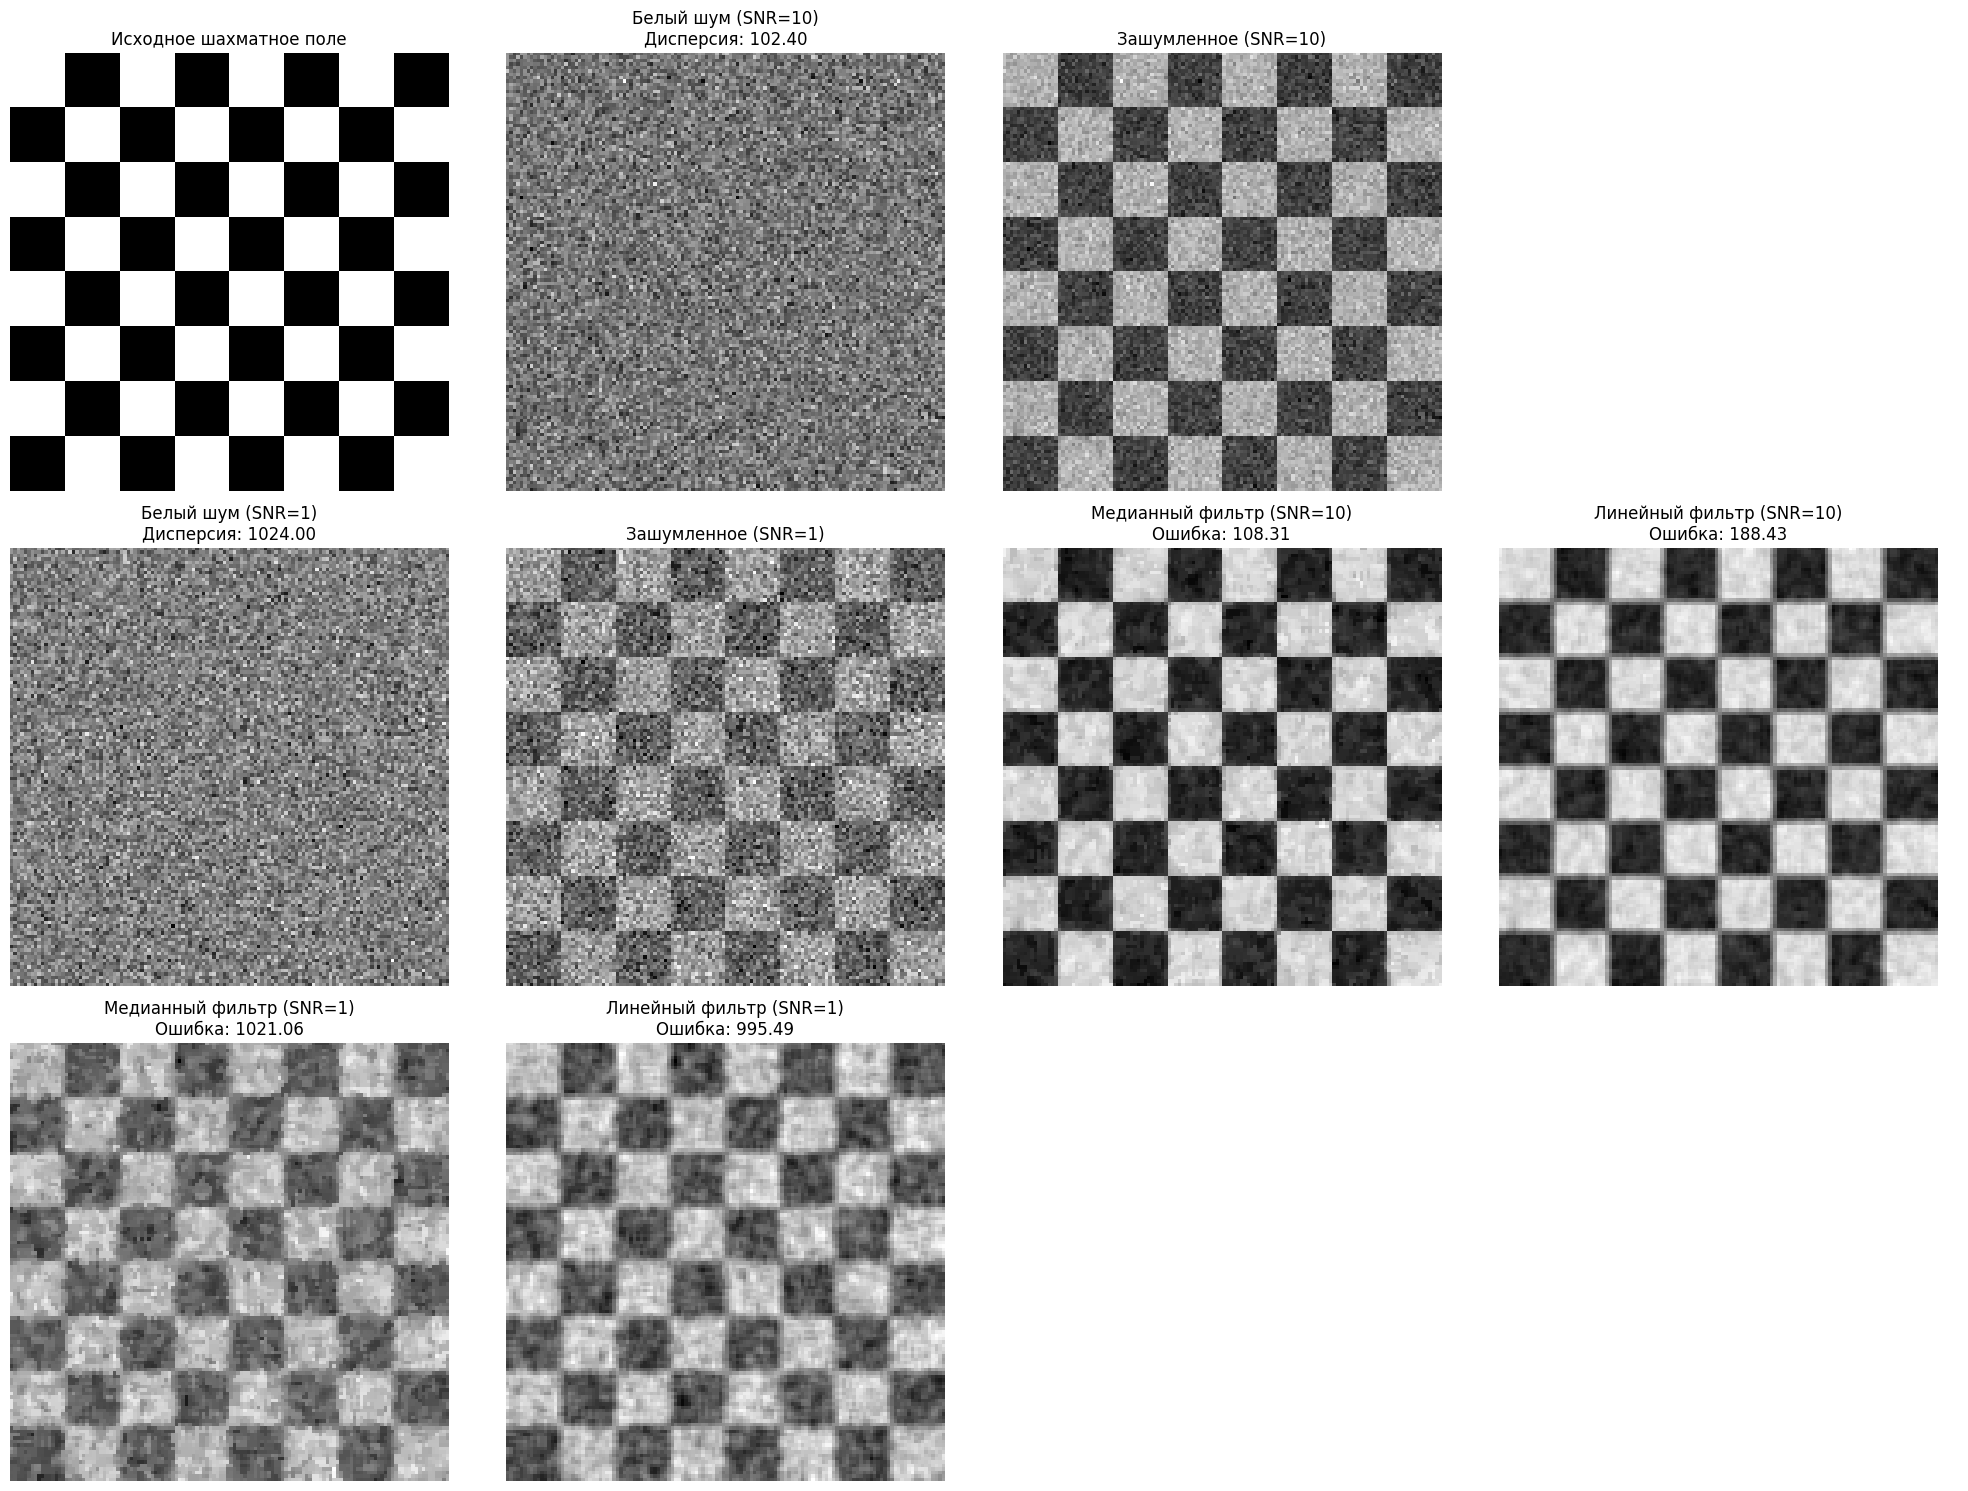

In [17]:
print("=== ЧАСТЬ 1: АДДИТИВНЫЙ БЕЛЫЙ ШУМ ===\n")

# Создаем шахматное поле
chessboard = generate_chessboard()
original_variance = calculate_variance(chessboard)
print(f"Дисперсия исходного изображения: {original_variance:.2f}")

# Эксперименты с разным SNR
snr_values = [10, 1]
results_gaussian = {}

for snr in snr_values:
    print(f"\n--- SNR = {snr} ---")
    
    # Добавление шума
    noisy_img, noise, noise_variance = add_gaussian_noise(chessboard, snr)
    noisy_variance = calculate_variance(noisy_img)
    
    print(f"Дисперсия шума: {noise_variance:.2f}")
    print(f"Дисперсия зашумленного изображения: {noisy_variance:.2f}")
    
    # Медианная фильтрация
    median_filtered, median_error_var, median_suppression = median_filter_image(noisy_img)
    
    # Линейная фильтрация
    linear_filtered, linear_error_var, linear_suppression = linear_filter_image(noisy_img)
    
    print(f"Медианный фильтр - дисперсия ошибки: {median_error_var:.2f}")
    print(f"Медианный фильтр - коэф. подавления: {median_suppression:.2f}")
    print(f"Линейный фильтр - дисперсия ошибки: {linear_error_var:.2f}")
    print(f"Линейный фильтр - коэф. подавления: {linear_suppression:.2f}")
    
    results_gaussian[snr] = {
        'noisy': noisy_img,
        'noise': noise,
        'noise_variance': noise_variance,
        'median_filtered': median_filtered,
        'median_error_var': median_error_var,
        'median_suppression': median_suppression,
        'linear_filtered': linear_filtered,
        'linear_error_var': linear_error_var,
        'linear_suppression': linear_suppression
    }

# Визуализация результатов для аддитивного шума
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Исходное изображение
axes[0, 0].imshow(chessboard, cmap='gray')
axes[0, 0].set_title('Исходное шахматное поле')
axes[0, 0].axis('off')

# Шумы и зашумленные изображения для SNR=10
axes[0, 1].imshow(results_gaussian[10]['noise'], cmap='gray')
axes[0, 1].set_title(f'Белый шум (SNR=10)\nДисперсия: {results_gaussian[10]["noise_variance"]:.2f}')
axes[0, 1].axis('off')

axes[0, 2].imshow(results_gaussian[10]['noisy'], cmap='gray')
axes[0, 2].set_title('Зашумленное (SNR=10)')
axes[0, 2].axis('off')

axes[0, 3].axis('off')  # Пустая ячейка для выравнивания

# Шумы и зашумленные изображения для SNR=1
axes[1, 0].imshow(results_gaussian[1]['noise'], cmap='gray')
axes[1, 0].set_title(f'Белый шум (SNR=1)\nДисперсия: {results_gaussian[1]["noise_variance"]:.2f}')
axes[1, 0].axis('off')

axes[1, 1].imshow(results_gaussian[1]['noisy'], cmap='gray')
axes[1, 1].set_title('Зашумленное (SNR=1)')
axes[1, 1].axis('off')

# Фильтрованные изображения для SNR=10
axes[1, 2].imshow(results_gaussian[10]['median_filtered'], cmap='gray')
axes[1, 2].set_title(f'Медианный фильтр (SNR=10)\nОшибка: {results_gaussian[10]["median_error_var"]:.2f}')
axes[1, 2].axis('off')

axes[1, 3].imshow(results_gaussian[10]['linear_filtered'], cmap='gray')
axes[1, 3].set_title(f'Линейный фильтр (SNR=10)\nОшибка: {results_gaussian[10]["linear_error_var"]:.2f}')
axes[1, 3].axis('off')

# Фильтрованные изображения для SNR=1
axes[2, 0].imshow(results_gaussian[1]['median_filtered'], cmap='gray')
axes[2, 0].set_title(f'Медианный фильтр (SNR=1)\nОшибка: {results_gaussian[1]["median_error_var"]:.2f}')
axes[2, 0].axis('off')

axes[2, 1].imshow(results_gaussian[1]['linear_filtered'], cmap='gray')
axes[2, 1].set_title(f'Линейный фильтр (SNR=1)\nОшибка: {results_gaussian[1]["linear_error_var"]:.2f}')
axes[2, 1].axis('off')

axes[2, 2].axis('off')
axes[2, 3].axis('off')

plt.tight_layout()
plt.show()

# Импульсный шум